In [16]:
import numpy as np
import qiskit as q
from qiskit import QuantumCircuit, transpile, assemble, QuantumRegister, AncillaRegister
from qiskit_aer import AerSimulator

from qiskit.quantum_info.operators import Operator
from qiskit.quantum_info import Statevector
from qiskit.visualization import array_to_latex
import matplotlib as mpl
import matplotlib.pyplot as plt

from qiskit_ibm_runtime.fake_provider import FakeBrisbane
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit.visualization import plot_histogram, plot_state_city

In [2]:
#parameters

M = 64 # lattices

w1 = 0.5 
w2 = 0.5 
e1 = 1   ##right
e2 = -1  ##left
cs = 1   ##speed of sound
u = 0.2  ##advection 


x = w1*(1+e1*u/cs**2)
y = w2*(1+e2*u/cs**2)

lambda1 = np.arccos(x)
lambda2 = np.arccos(y)

x,y

(0.6, 0.4)

In [3]:
def oneStep(lambda1,lambda2):
    
    #initializing
    n = int(np.log2(2*M))
    q = QuantumRegister(n,'q')
    a = AncillaRegister(1,'a')

    qc = QuantumCircuit(q)
    qc.add_register(a)
    
    
    qc.barrier()

    #collisions
    def createC(lambda1, lambda2, isC1 = True):
    
        if not isC1:
            lambda1 *= -1
            lambda2 *= -1


        qc=QuantumCircuit(2)

        #phase1 -> x -> phase1 -> x -----ctrl=0
        qc.cp(lambda1, 0 ,1 , ctrl_state = 0)
        qc.cx(0, 1, ctrl_state = 0)
        qc.cp(lambda1, 0, 1, ctrl_state = 0)
        qc.cx(0, 1, ctrl_state = 0)

        #phase2 -> x -> phase2 -> x -----ctrl=1 is default
        qc.cp(lambda2, 0, 1, ctrl_state = 1)
        qc.cx(0, 1)
        qc.cp(lambda2, 0, 1, ctrl_state = 1)
        qc.cx(0, 1)

        return qc
    
    C1 = createC(lambda1, lambda2, True)
    c1gate = C1.to_gate(label = 'c1')
    C2 = createC(lambda1, lambda2, False)
    c2gate = C2.to_gate(label = 'c2')
    
    
    #####adding steps to circuit
    qc.h(a)
    qc.append(c1gate.control(1, ctrl_state = 0),[a,n-1,0])
    qc.append(c2gate.control(1, ctrl_state = 1),[a,n-1,0])
    qc.h(a)
    qc.draw()
    
    
    
    #propagation
    def rshift(n):
        circ = QuantumCircuit(n-1)
        for i in range(n-1):
            if i == n-2:
                circ.x(i)
            else:
                circ.mcx(list(range(i+1,n-1)), i)
        return circ

    def lshift(n):
        circ = QuantumCircuit(n-1)
        for i in reversed(range(n-1)):
            if i == n-2:
                circ.x(i)
            else:
                circ.mcx(list(range(i+1,n-1)), i)
        return circ
    
    qc.barrier()
    R = rshift(n).to_gate(label = "R").control(1, ctrl_state = 0)#.control(1, ctrl_state = 0)
    L = lshift(n).to_gate(label = "L").control(1, ctrl_state = 1)#.control(1, ctrl_state = 0)
    
    cbits = [n-1]
    cbits.extend([i for i in range(n-2,-1,-1)])  

    qc.append(R,cbits)
    qc.append(L,cbits)

    
    ######################### macros
    qc.swap(a,n-1)
    qc.h(a)
#     qc.h(n-1)

    return qc

In [4]:
qc = oneStep(np.arccos(x),np.arccos(y))
# the following line throws a no attribute error
# qc.draw().savefig('qd1q2.pdf') # saves the circuit in a file called qd1q2
qc.draw() # draws circuit

░      ┌─────┐┌─────┐      ░ ┌────┐┌────┐        
q_0: ─░──────┤1    ├┤1    ├──────░─┤5   ├┤5   ├────────
      ░      │     ││     │      ░ │    ││    │        
q_1: ─░──────┤     ├┤     ├──────░─┤4   ├┤4   ├────────
      ░      │     ││     │      ░ │    ││    │        
q_2: ─░──────┤     ├┤     ├──────░─┤3   ├┤3   ├────────
      ░      │     ││     │      ░ │  R ││  L │        
q_3: ─░──────┤  c1 ├┤  c2 ├──────░─┤2   ├┤2   ├────────
      ░      │     ││     │      ░ │    ││    │        
q_4: ─░──────┤     ├┤     ├──────░─┤1   ├┤1   ├────────
      ░      │     ││     │      ░ │    ││    │        
q_5: ─░──────┤     ├┤     ├──────░─┤0   ├┤0   ├────────
      ░      │     ││     │      ░ └─┬──┘└─┬──┘        
q_6: ─░──────┤0    ├┤0    ├──────░───o─────■────X──────
      ░ ┌───┐└──┬──┘└──┬──┘┌───┐ ░              │ ┌───┐
  a: ─░─┤ H ├───o──────■───┤ H ├─░──────────────X─┤ H ├
      ░ └───┘              └───┘ ░                └───┘

In [105]:
#### initialState
initState = np.ones(M)/10  #0.1 everywhere
initState[12] = 0.2
nrm = np.linalg.norm(initState)
initState = np.concatenate((initState,initState))
#### statevector

SV = Statevector(initState/np.linalg.norm(initState)).expand([1,0])
initSV = SV #save for future reference


# Objective: simulate a single timestep on a simulator

In [117]:
# prepare the initial quantum state
circ = QuantumCircuit(qc.num_qubits)
circ.prepare_state(SV)

In [118]:
circ.append(qc, list(range(qc.num_qubits)))

In [119]:
print(circ.depth())
print(circ.num_qubits)

2
8


In [120]:
circ_copy = circ.copy()
circ_copy.measure_all()

In [121]:
# if I recall correctly, FakeBrisbane() has 127 qubits
# simulator = AerSimulator.from_backend(FakeBrisbane())
simulator = AerSimulator()

In [122]:
circ_copy = transpile(circ_copy, simulator)

In [123]:
result = simulator.run(circ_copy, shots=100_000).result()
counts = result.get_counts(circ)

In [124]:
counts = counts.int_outcomes()

In [125]:
keys = list(counts.keys())
keys.sort()
sorted_counts = {i: counts[i] for i in keys}

In [126]:
sorted_counts

{0: 374,
 1: 365,
 2: 357,
 3: 334,
 4: 364,
 5: 356,
 6: 384,
 7: 367,
 8: 383,
 9: 387,
 10: 395,
 11: 694,
 12: 371,
 13: 923,
 14: 358,
 15: 381,
 16: 354,
 17: 383,
 18: 372,
 19: 387,
 20: 362,
 21: 370,
 22: 369,
 23: 390,
 24: 368,
 25: 373,
 26: 389,
 27: 365,
 28: 370,
 29: 365,
 30: 397,
 31: 366,
 32: 354,
 33: 334,
 34: 398,
 35: 364,
 36: 376,
 37: 370,
 38: 366,
 39: 348,
 40: 372,
 41: 370,
 42: 388,
 43: 343,
 44: 360,
 45: 355,
 46: 370,
 47: 367,
 48: 340,
 49: 374,
 50: 342,
 51: 395,
 52: 391,
 53: 333,
 54: 418,
 55: 362,
 56: 386,
 57: 368,
 58: 391,
 59: 375,
 60: 365,
 61: 364,
 62: 377,
 63: 373,
 64: 1120,
 65: 1144,
 66: 1047,
 67: 1139,
 68: 1088,
 69: 1111,
 70: 1096,
 71: 1094,
 72: 1095,
 73: 1134,
 74: 1126,
 75: 2642,
 76: 1096,
 77: 2360,
 78: 1052,
 79: 1078,
 80: 1108,
 81: 1081,
 82: 1097,
 83: 1148,
 84: 1167,
 85: 1124,
 86: 1099,
 87: 1145,
 88: 1124,
 89: 1044,
 90: 1103,
 91: 1096,
 92: 1134,
 93: 1076,
 94: 1131,
 95: 1098,
 96: 1068,
 97: 10

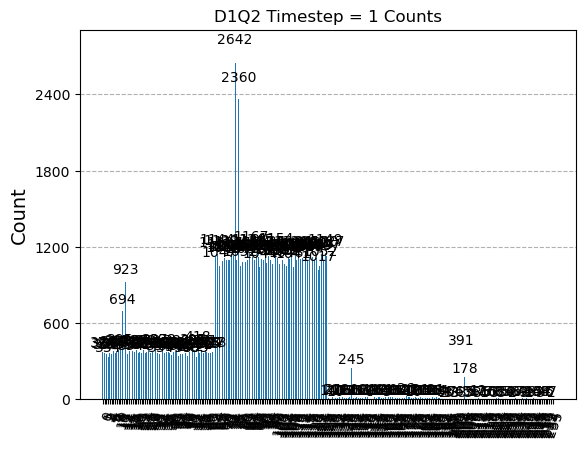

In [127]:
plot_histogram(counts, title="D1Q2 Timestep = 1 Counts")

# Objective: simulate final state on simulator

In [19]:
def timestep(sv):
    return sv.evolve(qc)

def graph(sv, color = "red"):
    plt.plot(list(range(0,M,1)), np.array(sv)[:M:1],color)
    plt.plot(list(range(M,2*M,1)), np.array(sv)[M:2*M:1],color)
    plt.plot(list(range(2*M,3*M,1)), np.array(sv)[2*M:3*M:1],color)
    plt.plot(list(range(3*M,4*M,1)), np.array(sv)[3*M::1],color)
    
def hres(sv):
    plt.plot(list(range(0,M,1)), 2**(1)*nrm*np.array(sv)[:M:])
    plt.xlabel("Lattice site")
    plt.ylabel("Concentration")
def hres2(sv):
    plt.plot(list(range(0,M,1)), 2**(1)*nrm2*np.array(sv)[:M:])  
def reinit(sv):
    tmp = np.array(sv)[:M]
    tmp = np.concatenate((tmp,tmp))
    return Statevector(tmp/np.linalg.norm(tmp)).expand([1,0])

In [133]:
def simulate(sv, qc):
    simulator = AerSimulator.from_backend(FakeBrisbane())
    # prepare the state of the given state vector
    circ = QuantumCircuit(qc.num_qubits)
    circ.prepare_state(sv)
    circ.measure_all()

    circ = transpile(circ, simulator)
    result = simulator.run(circ, shots=100_000).result()
    counts = result.get_counts(circ)
    return counts

In [134]:
# RESET
#### initialState
initState = np.ones(M)/10  #0.1 everywhere
initState[12] = 0.2
nrm = np.linalg.norm(initState)
initState = np.concatenate((initState,initState))
#### statevector

SV = Statevector(initState/np.linalg.norm(initState)).expand([1,0])
initSV = SV #save for future reference


In [135]:
# hres(initSV)
for i in range(1,51):
    print(i)
    SV = timestep(SV)
    if i==50:
        counts = simulate(SV, qc)
    SV = reinit(SV)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50


In [136]:
counts

{'10000001': 100,
 '10111000': 99,
 '10101100': 127,
 '10000000': 80,
 '10001100': 114,
 '10011010': 119,
 '11001001': 141,
 '10010111': 95,
 '11001100': 140,
 '10010101': 101,
 '10011101': 105,
 '10110000': 88,
 '10111100': 119,
 '11111010': 185,
 '10001010': 135,
 '11100001': 118,
 '11111100': 164,
 '10110011': 90,
 '11001111': 131,
 '11110010': 151,
 '10010001': 101,
 '10001001': 127,
 '10111010': 130,
 '11101011': 122,
 '11101110': 149,
 '10000011': 99,
 '11000100': 121,
 '11010010': 175,
 '10110111': 102,
 '11110100': 127,
 '11000110': 132,
 '11100000': 113,
 '10010100': 93,
 '11011011': 169,
 '11110101': 134,
 '11011111': 169,
 '11011010': 173,
 '10011001': 109,
 '11100010': 128,
 '01010000': 778,
 '11000111': 121,
 '10000100': 75,
 '11100110': 126,
 '00010111': 520,
 '00001101': 517,
 '11000001': 114,
 '10010010': 104,
 '11100100': 133,
 '11101111': 156,
 '10010011': 92,
 '11110011': 131,
 '01110011': 802,
 '11110001': 148,
 '11101000': 143,
 '01110010': 783,
 '10101111': 129,
 

In [148]:
vals = np.array(list(sorted_counts.values()))
vals = vals / np.linalg.norm(vals)

Text(0, 0.5, 'Concentration')

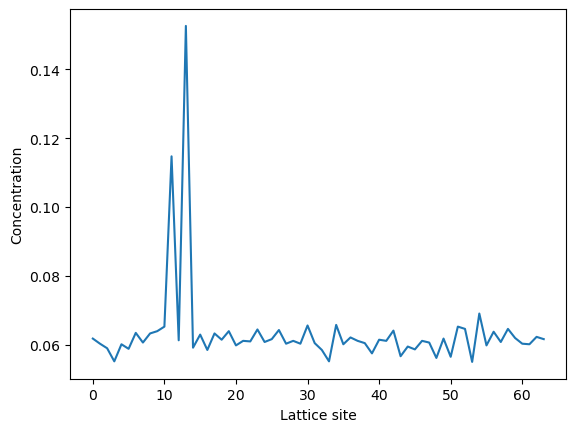

In [155]:
plt.plot(list(range(0,M,1)), 2**(1)*nrm*vals[:M:])
plt.xlabel("Lattice site")
plt.ylabel("Concentration")

In [22]:
# #### initialState
# x0 = 32
# sig = 4/np.sqrt(2)
# tmar = [-(pos-x0)**2/(2*sig**2) for pos in range(64)]
# tmar = np.exp(tmar)
# nrm2 = np.linalg.norm(tmar)
# tmar = np.concatenate((tmar,tmar))
# #### statevector

# SV2 = Statevector(tmar/np.linalg.norm(tmar)).expand([1,0])
# initSV2 = SV2 #save for future reference

In [ ]:
# hres(initSV2)
# for i in range(1,51):
#     SV2 = timestep(SV2)
#     if i%10==0:
#         hres2(SV2)
#     SV2 = reinit(SV2)